# 2.2 数据下载与处理
## 下载实验所需模块

In [1]:
!pip install download
%env no_proxy='a.test.com,127.0.0.1,2.2.2.2'

Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple
env: no_proxy='a.test.com,127.0.0.1,2.2.2.2'


## 数据下载

In [3]:
from download import download
url = "https://download.mindspore.cn/dataset/Faces/faces.zip"
path = download(url, "./faces", kind="zip", replace=True)

Creating data folder...

file_sizes: 100%|█████████████████████████████| 288M/288M [07:45<00:00, 618kB/s]
Extracting zip file...
Successfully downloaded / unzipped to ./faces


## 相关定义

In [15]:
batch_size = 256          # 批量大小
image_size = 64           # 训练图像空间大小
nc = 3                    # 图像彩色通道数
nz = 100                  # 隐向量的长度
ngf = 64                  # 特征图在生成器中的大小
ndf = 64                  # 特征图在判别器中的大小
num_epochs = 10           # 训练周期数
lr = 0.0002               # 学习率
lr_G = 0.0002  # 生成器保持不变
lr_D = 0.0001  # 判别器学习率减半（优先推荐）
beta1 = 0.5               # Adam优化器的beta1超参数

## 步骤 4定义`create_dataset_imagenet`函数对数据进行处理和增强操作。

In [16]:
import numpy as np
import mindspore.dataset as ds
import mindspore.dataset.vision as vision

def create_dataset_imagenet(dataset_path):
    """数据加载"""
    dataset = ds.ImageFolderDataset(dataset_path,
                                    num_parallel_workers=4,
                                    shuffle=True,
                                    decode=True)

    # 数据增强操作
    transforms = [
        vision.Resize(image_size),
        vision.CenterCrop(image_size),
        vision.HWC2CHW(),
        lambda x: ((x / 255).astype("float32"))
    ]

    # 数据映射操作
    dataset = dataset.project('image')
    dataset = dataset.map(transforms, 'image')

    # 批量操作
    dataset = dataset.batch(batch_size)
    return dataset

dataset = create_dataset_imagenet('./faces')

In [17]:
## 步骤 5通过create_dict_iterator函数将数据转换成字典迭代器，然后使用`matplotlib`模块可视化部分训练数据。

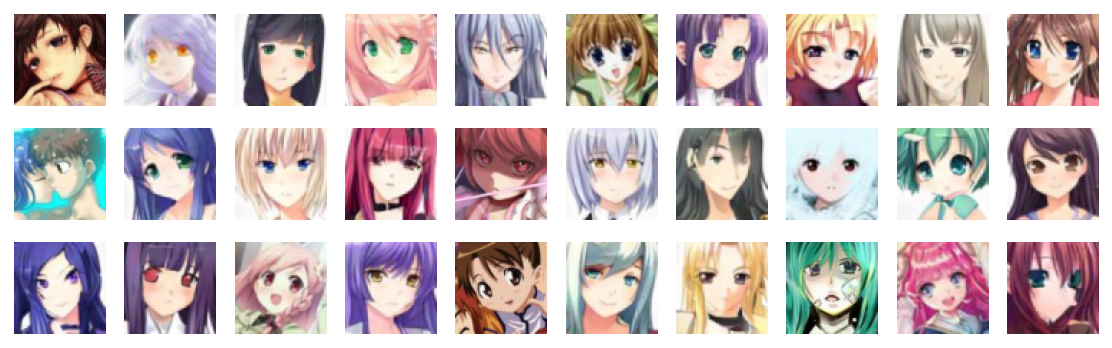

In [18]:
import matplotlib.pyplot as plt
def plot_data(data):
    # 可视化部分训练数据
    plt.figure(figsize=(10, 3), dpi=140)
    for i, image in enumerate(data[0][:30], 1):
        plt.subplot(3, 10, i)
        plt.axis("off")
        plt.imshow(image.transpose(1, 2, 0))
    plt.savefig("./watch.png")
    plt.show()

sample_data = next(dataset.create_tuple_iterator(output_numpy=True))
plot_data(sample_data)

In [19]:
# 生成器的代码实现

In [20]:
import mindspore as ms
from mindspore import nn, ops
from mindspore.common.initializer import Normal

weight_init = Normal(mean=0, sigma=0.02)
gamma_init = Normal(mean=1, sigma=0.02)

class Generator(nn.Cell):
    """DCGAN网络生成器"""

    def __init__(self):
        super(Generator, self).__init__()
        self.generator = nn.SequentialCell(
            nn.Conv2dTranspose(nz, ngf * 8, 4, 1, 'valid', weight_init=weight_init),
            nn.BatchNorm2d(ngf * 8, gamma_init=gamma_init),
            nn.ReLU(),
            nn.Conv2dTranspose(ngf * 8, ngf * 4, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.BatchNorm2d(ngf * 4, gamma_init=gamma_init),
            nn.ReLU(),
            nn.Conv2dTranspose(ngf * 4, ngf * 2, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.BatchNorm2d(ngf * 2, gamma_init=gamma_init),
            nn.ReLU(),
            nn.Conv2dTranspose(ngf * 2, ngf, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.BatchNorm2d(ngf, gamma_init=gamma_init),
            nn.ReLU(),
            nn.Conv2dTranspose(ngf, nc, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.Tanh()
            )

    def construct(self, x):
        return self.generator(x)

generator = Generator()

In [21]:
# 步骤 2判别器

In [22]:
class Discriminator(nn.Cell):
    """DCGAN网络判别器"""

    def __init__(self):
        super(Discriminator, self).__init__()
        self.discriminator = nn.SequentialCell(
            nn.Conv2d(nc, ndf, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.BatchNorm2d(ngf * 2, gamma_init=gamma_init),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.BatchNorm2d(ngf * 4, gamma_init=gamma_init),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 'pad', 1, weight_init=weight_init),
            nn.BatchNorm2d(ngf * 8, gamma_init=gamma_init),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf * 8, 1, 4, 1, 'valid', weight_init=weight_init),
            )
        self.adv_layer = nn.Sigmoid()

    def construct(self, x):
        out = self.discriminator(x)
        out = out.reshape(out.shape[0], -1)
        return self.adv_layer(out)

discriminator = Discriminator()

In [23]:
# 定义损失函数
adversarial_loss = nn.BCELoss(reduction='mean')
# 为生成器和判别器设置优化器
optimizer_D = nn.Adam(discriminator.trainable_params(), learning_rate=lr_D, beta1=beta1)
optimizer_G = nn.Adam(generator.trainable_params(), learning_rate=lr_G, beta1=beta1)
optimizer_G.update_parameters_name('optim_g.')
optimizer_D.update_parameters_name('optim_d.')

In [24]:
def generator_forward(real_imgs, valid):
    # 将噪声采样为发生器的输入
    z = ops.standard_normal((real_imgs.shape[0], nz, 1, 1))

    # 生成一批图像
    gen_imgs = generator(z)

    # 损失衡量发生器绕过判别器的能力
    g_loss = adversarial_loss(discriminator(gen_imgs), valid)

    return g_loss, gen_imgs

def discriminator_forward(real_imgs, gen_imgs, valid, fake):
    # 衡量鉴别器从生成的样本中对真实样本进行分类的能力
    real_loss = adversarial_loss(discriminator(real_imgs), valid)
    fake_loss = adversarial_loss(discriminator(gen_imgs), fake)
    d_loss = (real_loss + fake_loss) / 2
    return d_loss

grad_generator_fn = ms.value_and_grad(generator_forward, None,
                                      optimizer_G.parameters,
                                      has_aux=True)
grad_discriminator_fn = ms.value_and_grad(discriminator_forward, None,
                                          optimizer_D.parameters)

@ms.jit
def train_step(imgs):
    valid = ops.ones((imgs.shape[0], 1), mindspore.float32)
    fake = ops.zeros((imgs.shape[0], 1), mindspore.float32)
    (g_loss, gen_imgs), g_grads = grad_generator_fn(imgs, valid)
    optimizer_G(g_grads)
    d_loss, d_grads = grad_discriminator_fn(imgs, gen_imgs, valid, fake)
    optimizer_D(d_grads)

    return g_loss, d_loss, gen_imgs

In [25]:
import mindspore

G_losses = []
D_losses = []
image_list = []

total = dataset.get_dataset_size()
for epoch in range(num_epochs):
    generator.set_train()
    discriminator.set_train()
    # 为每轮训练读入数据
    for i, (imgs, ) in enumerate(dataset.create_tuple_iterator()):
        g_loss, d_loss, gen_imgs = train_step(imgs)
        if i % 100 == 0 or i == total - 1:
            # 输出训练记录
            print('[%2d/%d][%3d/%d]   Loss_D:%7.4f  Loss_G:%7.4f' % (
                epoch + 1, num_epochs, i + 1, total, d_loss.asnumpy(), g_loss.asnumpy()))
        D_losses.append(d_loss.asnumpy())
        G_losses.append(g_loss.asnumpy())

    # 每个epoch结束后，使用生成器生成一组图片
    generator.set_train(False)
    fixed_noise = ops.standard_normal((batch_size, nz, 1, 1))
    img = generator(fixed_noise)
    image_list.append(img.transpose(0, 2, 3, 1).asnumpy())

    # 保存网络模型参数为ckpt文件
    mindspore.save_checkpoint(generator, "./generator.ckpt")
    mindspore.save_checkpoint(discriminator, "./discriminator.ckpt")


[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:07:19.398.043 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:07:19.398.156 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:07:19.398.194 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:07:19.403.473 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:07:19.403.653 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:07:19.403.697 [mindspore/c

[ 1/10][  1/275]   Loss_D: 0.8734  Loss_G: 0.6430
[ 1/10][101/275]   Loss_D: 0.3926  Loss_G: 3.4467
[ 1/10][201/275]   Loss_D: 0.6653  Loss_G: 0.5426


[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:08:13.901.361 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:08:13.901.441 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:08:13.901.540 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:08:13.906.691 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:08:13.906.871 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_57867/3035621055.py]
[ERROR] CORE(57867,ffff91e690b0,python):2025-12-28-11:08:13.906.914 [mindspore/c

[ 1/10][275/275]   Loss_D: 0.3917  Loss_G: 0.8898
[ 2/10][  1/275]   Loss_D: 0.4485  Loss_G: 1.6425
[ 2/10][101/275]   Loss_D: 0.6468  Loss_G: 0.4643
[ 2/10][201/275]   Loss_D: 0.4164  Loss_G: 1.5533
[ 2/10][275/275]   Loss_D: 0.6990  Loss_G: 1.8664
[ 3/10][  1/275]   Loss_D: 0.9889  Loss_G: 0.2184
[ 3/10][101/275]   Loss_D: 0.4089  Loss_G: 1.1796
[ 3/10][201/275]   Loss_D: 0.5268  Loss_G: 2.3150
[ 3/10][275/275]   Loss_D: 0.7136  Loss_G: 0.6742
[ 4/10][  1/275]   Loss_D: 0.5275  Loss_G: 1.9970
[ 4/10][101/275]   Loss_D: 0.3826  Loss_G: 2.0438
[ 4/10][201/275]   Loss_D: 0.5498  Loss_G: 0.8422
[ 4/10][275/275]   Loss_D: 0.4121  Loss_G: 3.7360
[ 5/10][  1/275]   Loss_D: 0.2998  Loss_G: 1.2120
[ 5/10][101/275]   Loss_D: 0.4376  Loss_G: 0.9212
[ 5/10][201/275]   Loss_D: 0.3695  Loss_G: 1.7365
[ 5/10][275/275]   Loss_D: 0.3541  Loss_G: 0.9249
[ 6/10][  1/275]   Loss_D: 0.4058  Loss_G: 2.4788
[ 6/10][101/275]   Loss_D: 0.6106  Loss_G: 2.4193
[ 6/10][201/275]   Loss_D: 0.6196  Loss_G: 0.6057


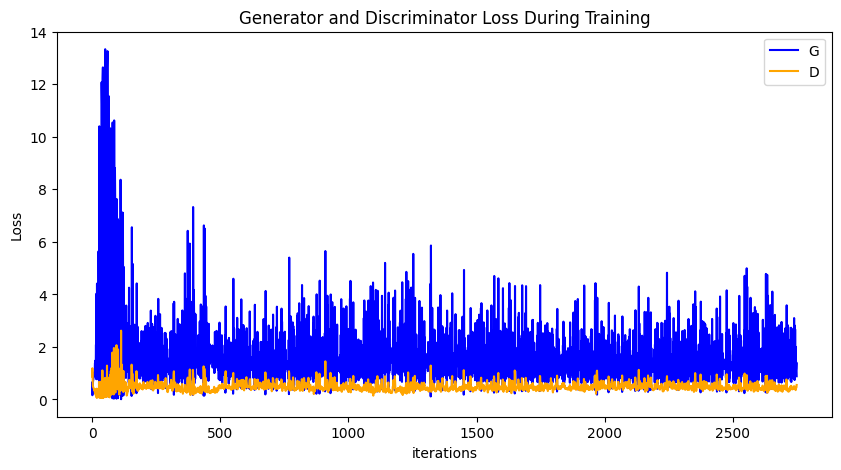

In [29]:
# 结果展示
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G", color='blue')
plt.plot(D_losses, label="D", color='orange')
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig("./a.png")
plt.show()

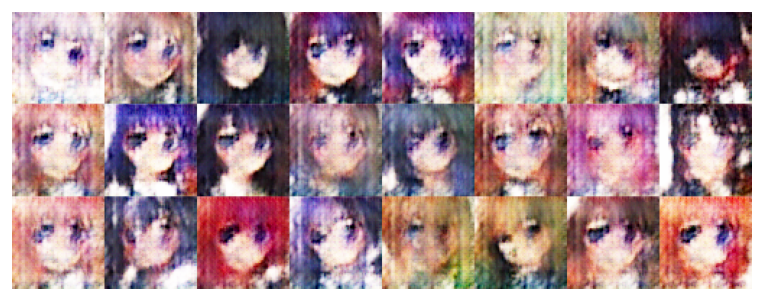

In [30]:
# 步骤 2可视化训练过程中通过隐向量`fixed_noise`生成的图像。
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def showGif(image_list):
    show_list = []
    fig = plt.figure(figsize=(8, 3), dpi=120)
    for epoch in range(len(image_list)):
        images = []
        for i in range(3):
            row = np.concatenate((image_list[epoch][i * 8:(i + 1) * 8]), axis=1)
            images.append(row)
        img = np.clip(np.concatenate((images[:]), axis=0), 0, 1)
        plt.axis("off")
        show_list.append([plt.imshow(img)])

    ani = animation.ArtistAnimation(fig, show_list, interval=1000, repeat_delay=1000, blit=True)
    ani.save('./dcgan.gif', writer='pillow', fps=1)

showGif(image_list)

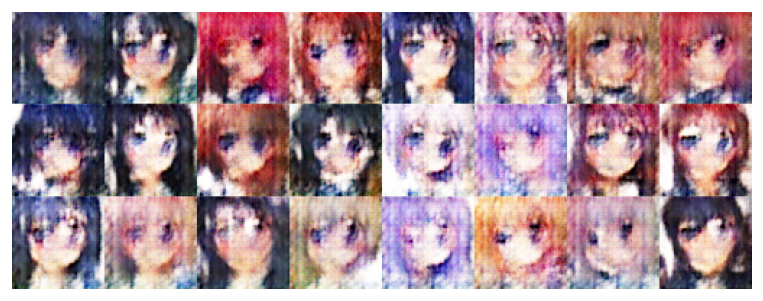

In [33]:
# 从文件中获取模型参数并加载到网络中
mindspore.load_checkpoint("./generator.ckpt", generator)
fixed_noise = ops.standard_normal((batch_size, nz, 1, 1))
img64 = generator(fixed_noise).transpose(0, 2, 3, 1).asnumpy()
fig = plt.figure(figsize=(8, 3), dpi=120)
images = []
for i in range(3):
    images.append(np.concatenate((img64[i * 8:(i + 1) * 8]), axis=1))
img = np.clip(np.concatenate((images[:]), axis=0), 0, 1)
plt.axis("off")
plt.imshow(img)
plt.savefig("./output.png")
plt.show()
